In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
import tiktoken

tokenizer_4 = tiktoken.get_encoding('cl100k_base')

In [3]:
from transformers import AutoTokenizer
tokenizer_2 = AutoTokenizer.from_pretrained('gpt2')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dir(tokenizer_4)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_core_bpe',
 '_encode_bytes',
 '_encode_only_native_bpe',
 '_encode_single_piece',
 '_mergeable_ranks',
 '_pat_str',
 '_special_token_values',
 '_special_tokens',
 'decode',
 'decode_batch',
 'decode_bytes',
 'decode_bytes_batch',
 'decode_single_token_bytes',
 'decode_tokens_bytes',
 'decode_with_offsets',
 'encode',
 'encode_batch',
 'encode_ordinary',
 'encode_ordinary_batch',
 'encode_single_token',
 'encode_to_numpy',
 'encode_with_unstable',
 'eot_token',
 'is_special_token',
 'max_token_value',
 'n_vocab',
 'name',
 'special_tokens_set

In [5]:
print(f'GPT-4 tokenizer has {tokenizer_4.n_vocab:7,} tokens.')
print(f'GPT-2 tokenizer has {tokenizer_2.vocab_size:7,} tokens.')

GPT-4 tokenizer has 100,277 tokens.
GPT-2 tokenizer has  50,257 tokens.


In [6]:
lengths_2 = np.zeros(tokenizer_2.vocab_size, dtype=int)
for t in range(tokenizer_2.vocab_size):
    lengths_2[t] = len(tokenizer_2.decode(t).encode('utf-8'))

lengths_2 = [len(tokenizer_2.decode(t).encode('utf-8')) for t in range(tokenizer_2.vocab_size)]

In [7]:
lengths_4 = np.zeros(tokenizer_4.n_vocab, dtype=int)

for t in range(tokenizer_4.n_vocab):
    try:
        lengths_4[t] = len(tokenizer_4.decode([t]).encode('utf-8'))
    except:
        lengths_4[t] = -1

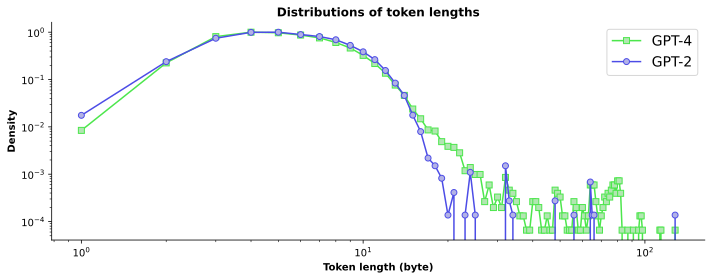

In [8]:
bincounts_2 = np.bincount(lengths_2)
bincounts_4 = np.bincount(lengths_4[lengths_4>-1])

plt.figure(figsize=(10,4))
plt.plot(range(1,max(lengths_4)+1),bincounts_4[1:]/bincounts_4.max(),'s-',color=[.3,.9,.3],markerfacecolor=[.7,.9,.7],label='GPT-4')
plt.plot(range(1,max(lengths_2)+1),bincounts_2[1:]/bincounts_2.max(),'o-',color=[.3,.3,.9],markerfacecolor=[.7,.7,.9],label='GPT-2')

plt.legend(fontsize=14)
plt.gca().set(xlabel='Token length (byte)',ylabel='Density', title='Distributions of token lengths',yscale='log',xscale='log')

plt.tight_layout()
plt.savefig('ch2_proj7_part2.png')
plt.show()

In [9]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

In [11]:
tokens_2 = np.zeros(len(bookurls))
tokens_4 = np.zeros(len(bookurls))
token_lens_2 = np.zeros(len(bookurls))
token_lens_4 = np.zeros(len(bookurls))

for i, (code, title) in enumerate(bookurls):
    fullurl = baseurl + code + '/pg' + code + '.txt'
    text = requests.get(fullurl).text

    gpt2_toks = tokenizer_2.encode(text)
    gpt4_toks = tokenizer_4.encode(text)

    tokens_2[i] = len(gpt2_toks)
    tokens_4[i] = len(gpt4_toks)

    token_lens_2[i] = np.mean([len(tokenizer_2.decode(t).encode('utf-8'))   for t in gpt2_toks])
    token_lens_4[i] = np.mean([len(tokenizer_4.decode([t]).encode('utf-8')) for t in gpt4_toks])


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


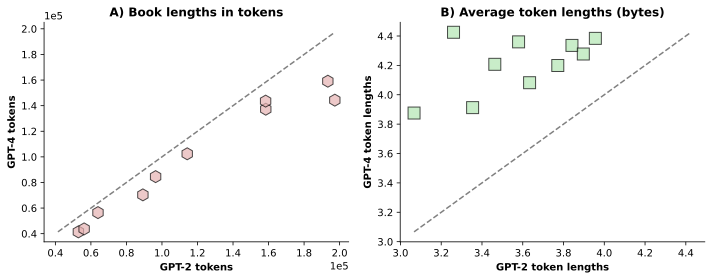

In [12]:
_, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0] .plot(tokens_2, tokens_4, 'kh', markerfacecolor=[.9,.7,.7,.7], markersize=12)

minlength = np.min([np.min(tokens_2), np.min(tokens_4)])
maxlength = np.max([np.max(tokens_2), np.max(tokens_4)])
axs[0].plot([minlength, maxlength], [minlength, maxlength], '--', color=[.5, .5, .5])

axs[0].set(xlabel='GPT-2 tokens',ylabel='GPT-4 tokens',title='A) Book lengths in tokens')
axs[0].ticklabel_format(style='scientific',axis='both',scilimits=(0,0))

axs[1].plot(token_lens_2,token_lens_4,'ks',markerfacecolor=[.7,.9,.7,.7],markersize=12)

minlength = np.min([np.min(token_lens_2),np.min(token_lens_4)])
maxlength = np.max([np.max(token_lens_2),np.max(token_lens_4)])
axs[1].plot([minlength,maxlength],[minlength,maxlength],'--',color=[.5,.5,.5])

axs[1].set(xlabel='GPT-2 token lengths',ylabel='GPT-4 token lengths',title='B) Average token lengths (bytes)')


plt.tight_layout()
plt.savefig('ch2_proj7_part3.png')
plt.show()

In [13]:
def gpt2_to_4(toks):
    newtxt = tokenizer_2.decode(toks)
    newtoks = tokenizer_4.encode(newtxt)
    return newtoks

def gpt4_to_2(toks):
    return tokenizer_2.encode(tokenizer_4.decode(toks))

In [15]:
text = 'Canadian winters are kept WArM bY the friendliness of THE PEOPLE.'
print('Original text:\n ',text,'\n')

toks_2 = tokenizer_2.encode(text)
toks_4 = tokenizer_4.encode(text)

print('GPT-2 tokens:\n ', toks_2)
print('GPT-4 tokens:\n ', toks_4, '\n')

print('GPT-2 reconstruction:\n ',tokenizer_2.decode(toks_2))
print('GPT-4 reconstruction:\n ',tokenizer_4.decode(toks_4),'\n')

print('GPT-2 to GPT-4 translation:\n ',tokenizer_4.decode(gpt2_to_4(toks_2)))
print('GPT-4 to GPT-2 translation:\n ',tokenizer_2.decode(gpt4_to_2(toks_4)))


Original text:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

GPT-2 tokens:
  [28203, 45764, 389, 4030, 370, 3163, 44, 275, 56, 262, 1545, 26061, 286, 3336, 36388, 13]
GPT-4 tokens:
  [60674, 86082, 527, 8774, 468, 7098, 44, 293, 56, 279, 4333, 49958, 315, 3247, 67825, 13] 

GPT-2 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.
GPT-4 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

GPT-2 to GPT-4 translation:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.
GPT-4 to GPT-2 translation:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE.
